# Augmented Reality with Planar Homographies

### Setup: Imports and Loading Videos

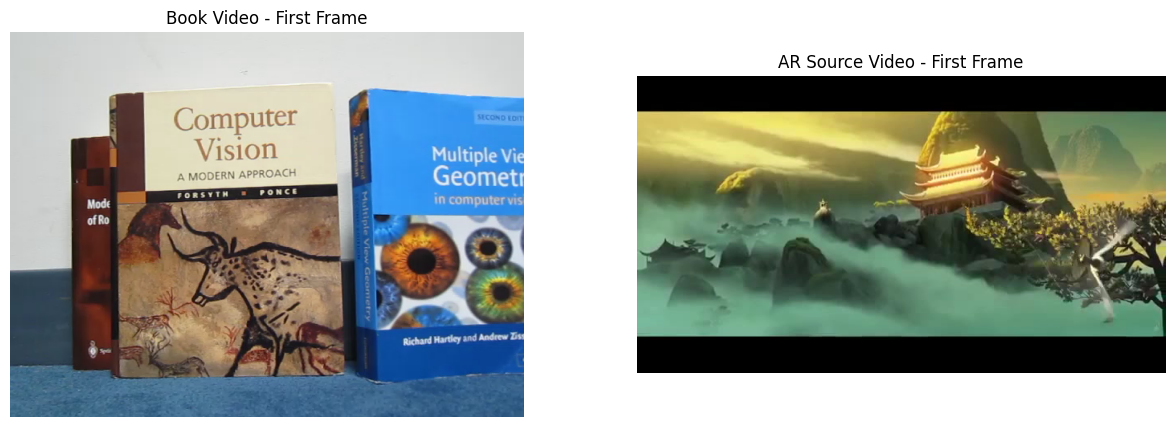

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

book_vid = cv2.VideoCapture('data/book.mov')
ar_vid = cv2.VideoCapture('data/ar_source.mov')

book_cover = cv2.imread('data/cv_cover.jpg')

# first frame of each video for testing
ret_book, book_frame_bgr = book_vid.read()
ret_ar, ar_frame_bgr = ar_vid.read()

# convert BGR to RGB for plotting
book_frame = cv2.cvtColor(book_frame_bgr, cv2.COLOR_BGR2RGB)
ar_frame = cv2.cvtColor(ar_frame_bgr, cv2.COLOR_BGR2RGB)

# width and height of book cover and ar video
h_book, w_book, _ = book_cover.shape
h_ar, w_ar, _ = ar_frame.shape

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.imshow(book_frame)
ax1.set_title('Book Video - First Frame')
ax1.axis('off')

ax2.imshow(ar_frame)
ax2.set_title('AR Source Video - First Frame')
ax2.axis('off')
        
plt.show()

### Getting Correspondences
The first step is to find the correspondences between the image book and the first frame of the video. 
- Use SIFT descriptor from opencv library to find keypoints in each image.
- Use the brute force matcher from opencv to get the correspondences. 
- Use the matching way as KNN with size 2
- apply ratio checking between the best 2 matches to filter the good correspondences.
- Choose 50 correspondences and plot the book image, the first video frame and the matches as shown below.

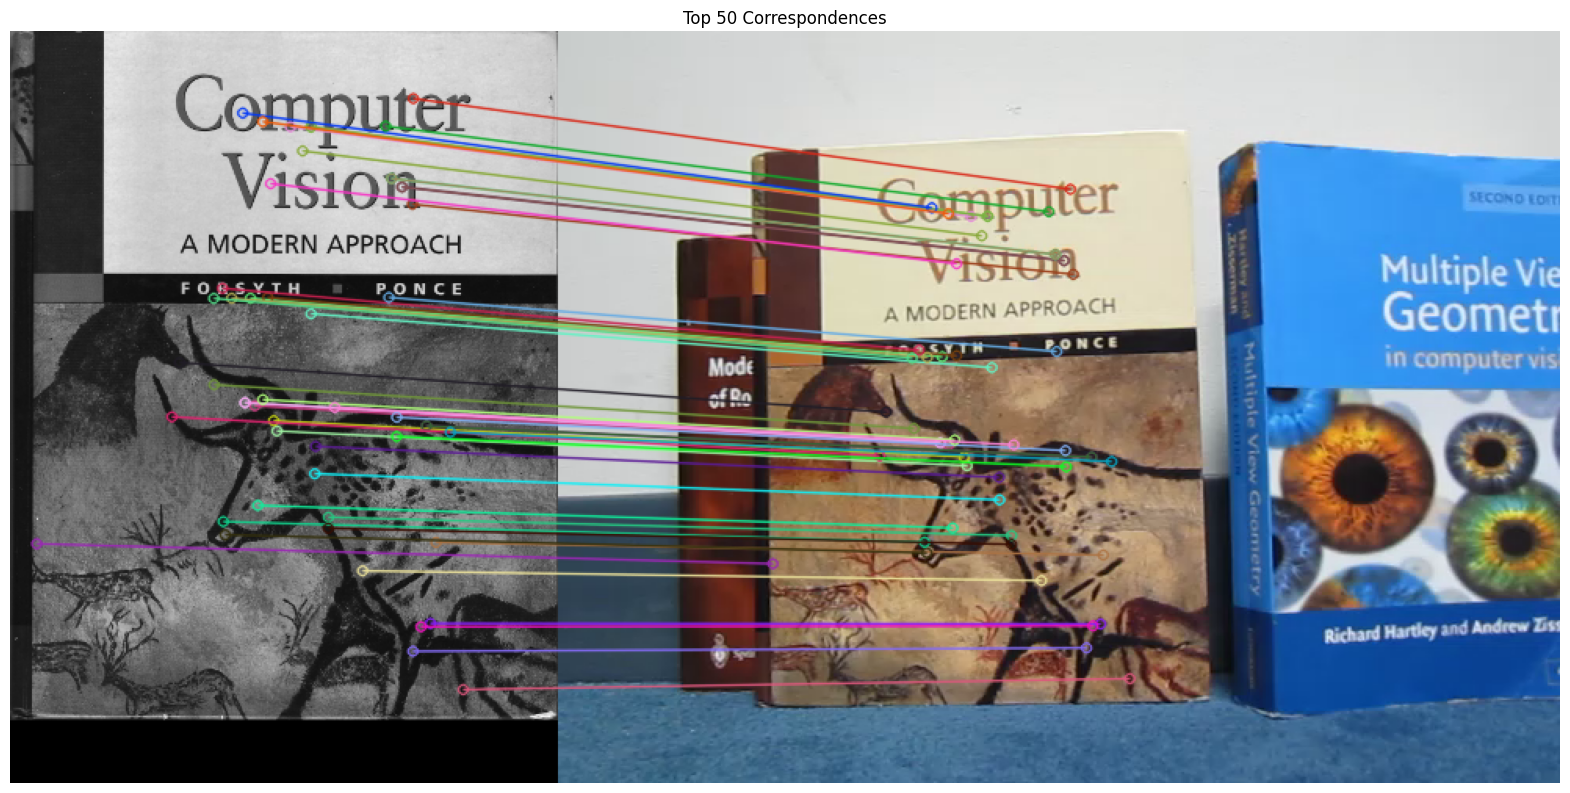

In [24]:
# grayscale for feature extraction
gray_cover = cv2.cvtColor(book_cover, cv2.COLOR_RGB2GRAY)
gray_book = cv2.cvtColor(book_frame, cv2.COLOR_RGB2GRAY)

sift = cv2.SIFT_create()

# get keypoints and descriptors
kp1, des1 = sift.detectAndCompute(gray_cover, None)
kp2, des2 = sift.detectAndCompute(gray_book, None)

# brute force matcher
bf = cv2.BFMatcher()

# KNN Matching with k=2
matches = bf.knnMatch(des1, des2, k=2)

# ratio checking for good correspondences
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

# get top 50 correspondences
good_matches = sorted(good_matches, key=lambda x: x.distance)
top_50_matches = good_matches[:50] 

# draw the matches
matched_img = cv2.drawMatches(
    book_cover, kp1, 
    book_frame, kp2, 
    top_50_matches, None, 
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(20, 10))
plt.imshow(matched_img)
plt.title('Top 50 Correspondences')
plt.axis('off')
plt.show()

### Compute the Homography Parameters
- A function is needed that takes a set of corresponding image points and computes the associated 3Ãƒâ€”3 homography matrix H. 
- This matrix transforms any point p in one view to its corresponding homogeneous coordinates in the second view, pÃ¢â‚¬â„¢, such that pÃ¢â‚¬â„¢ = Hp. 
- Note that p and pÃ¢â‚¬â„¢ are both 3D points in homogeneous coordinates. 
- The function should take a list of n >= 4 pairs of corre sponding points from the two views, where each point is specified with its 2D image coordinates. 
#### How to solve
- We can set up a solution using a system of linear equations Ax = b, where the 8 unknowns of H are stacked into an 8-vector x , the 2n-vector b contains image points from one view, and the 2n Ãƒâ€” 8 matrix A is filled appropriately so that the full system gives us ÃŽÂ»p = Hp. 
- There are only 8 unknowns in H because we set H3,3 = 1. 
- Solve for the unknown homography matrix parameters. 

$$H = \begin{bmatrix} h_{11} & h_{12} & h_{13} \\ h_{21} & h_{22} & h_{23} \\ h_{31} & h_{32} & 1 \end{bmatrix}$$

The relationship $p' = Hp$ gives us the following equations for the mapped coordinates:

$$x' = \frac{h_{11}x + h_{12}y + h_{13}}{h_{31}x + h_{32}y + 1}$$
$$y' = \frac{h_{21}x + h_{22}y + h_{23}}{h_{31}x + h_{32}y + 1}$$

By multiplying by the denominators and rearranging the terms to isolate the 8 unknowns, we can formulate a system of linear equations $Ax = b$. For a single corresponding point pair $(x, y)$ and $(x', y')$, the $2 \times 8$ sub-matrix $A_i$ and $2 \times 1$ sub-vector $b_i$ are structured as follows:

$$A_i = \begin{bmatrix} x & y & 1 & 0 & 0 & 0 & -x \cdot x' & -y \cdot x' \\ 0 & 0 & 0 & x & y & 1 & -x \cdot y' & -y \cdot y' \end{bmatrix}$$

$$b_i = \begin{bmatrix} x' \\ y' \end{bmatrix}$$

The vector $x$ contains our 8 unknowns:

$$x = \begin{bmatrix} h_{11} \\ h_{12} \\ h_{13} \\ h_{21} \\ h_{22} \\ h_{23} \\ h_{31} \\ h_{32} \end{bmatrix}$$

By stacking the $A_i$ and $b_i$ matrices for $n \ge 4$ point pairs, we create the full $2n \times 8$ matrix $A$ and the $2n$-vector $b$. We can then solve for the 8-vector $x$ using the Least Squares method.

- Verify that the homography matrix your function computes is correct by mapping a few image points from one view to the other, and displaying them on top of each respective image. 
- Be sure to handle homogenous and non-homogenous coordinates correctly.

In [25]:
def compute_homography_parameters(src_pts, dst_pts):
    A = []
    b = []
    
    # x = x
    # y = y
    # u = x'
    # v = y'
    
    for i in range(len(src_pts)):
        x, y = src_pts[i]
        u, v = dst_pts[i]
        
        A.append([x, y, 1, 0, 0, 0, -x*u, -y*u])
        A.append([0, 0, 0, x, y, 1, -x*v, -y*v])
        
        b.append(u)
        b.append(v)
        
    A = np.array(A)
    b = np.array(b)
    
    # least squares: Ax = b
    # x_vec contains the 8 unknowns
    x_vec, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    
    # reshape the vector to get 3x3 homography matrix
    H = np.append(x_vec, 1).reshape(3, 3)
    
    return H

In [26]:
# extract the (x, y) coordinates from the good matches
src_pts = np.float32([kp1[m.queryIdx].pt for m in top_50_matches])
dst_pts = np.float32([kp2[m.trainIdx].pt for m in top_50_matches])

# compute the homography matrix
H = compute_homography_parameters(src_pts, dst_pts)

print("Computed Homography Matrix H:")
print(H)

# verify: map the first 5 points from the cover to the video frame
for i in range(5):
    # homogeneous coordinates for the current point
    p_src = np.array([src_pts[i][0], src_pts[i][1], 1.0]) 
    
    # map the point using the homography matrix transformation
    p_dst_mapped = np.dot(H, p_src)
    p_dst_mapped = p_dst_mapped / p_dst_mapped[2] # normalize by Z
    
    print(f"Point {i+1}:")
    print(f"  Original Source Point: {src_pts[i]}")
    print(f"  Mapped Destination Point: [{p_dst_mapped[0]:.2f}, {p_dst_mapped[1]:.2f}]")
    print(f"  Actual Destination Point: {dst_pts[i]}")
    print()

Computed Homography Matrix H:
[[ 7.73593017e-01  2.87371880e-03  1.19526225e+02]
 [-5.08678829e-02  7.78871532e-01  7.74484352e+01]
 [-9.04286159e-05 -7.40298171e-05  1.00000000e+00]]
Point 1:
  Original Source Point: [129.84949 225.25644]
  Mapped Destination Point: [227.08, 253.49]
  Actual Destination Point: [226.94148 253.17487]

Point 2:
  Original Source Point: [169.9911  254.79167]
  Mapped Destination Point: [260.69, 276.72]
  Actual Destination Point: [260.78482 277.00305]

Point 3:
  Original Source Point: [149.65019 236.72469]
  Mapped Destination Point: [243.54, 262.36]
  Actual Destination Point: [243.73103 262.51007]

Point 4:
  Original Source Point: [191.79314   60.753185]
  Mapped Destination Point: [274.06, 117.58]
  Actual Destination Point: [273.90848  117.780266]

Point 5:
  Original Source Point: [107.89213 211.09807]
  Mapped Destination Point: [208.90, 242.53]
  Actual Destination Point: [209.10095 242.74455]



### Calculate Book Coordinates
Detect the four corners of the book in the video. This is done by mapping the four corners of the book image (cover) to the first frame in the book video using the homography matrix calculated previously.

Transform the cover coordinates at (0,0) , (width,0) , (width, height) , (0,height) using the H matrix to get the projected coordinates p.

Done


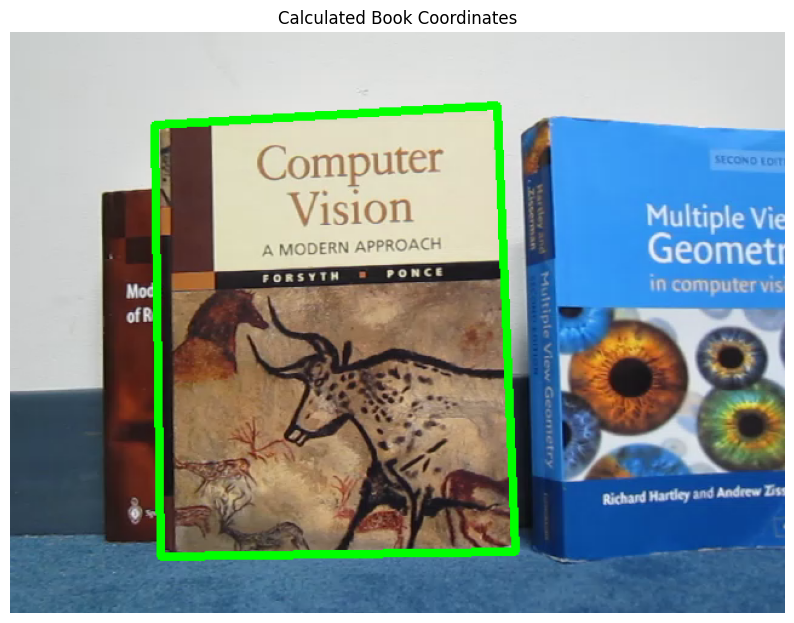

In [27]:
height, width = book_cover.shape[:2]

# corner coordinates
top_left = [0, 0]
top_right = [width - 1, 0]
bottom_left = [0, height - 1]
bottom_right = [width - 1, height - 1]

corners = [top_left, top_right, bottom_right, bottom_left]

corners_transformed = []

# map each corner using the Homography matrix
for corner in corners:
    corner_homogenous = np.array([corner[0], corner[1], 1.0])
    
    # apply homography
    p_mapped = np.dot(H, corner_homogenous)
    
    # normalize by Z
    p_mapped = p_mapped / p_mapped[2]
    
    corners_transformed.append([p_mapped[0], p_mapped[1]])

print("Done")

# integer coordinates for drawing
corners_dst = np.array(corners_transformed, dtype=np.int32)

# verify by drawing the bounding box on a copy of the video frame
# cv2.polylines takes an array of shape (num_curves, num_points, 2)
frame_with_box = book_frame.copy()
cv2.polylines(frame_with_box, [corners_dst], isClosed=True, color=(0, 255, 0), thickness=5)

plt.figure(figsize=(10, 8))
plt.imshow(frame_with_box)
plt.title('Calculated Book Coordinates')
plt.axis('off')
plt.show()

### Crop AR Video Frames
The book and the videos provided have very different aspect ratios (the ratio of the image width to the image height).
- Crop each frame to fit onto the book cover.
- Crop each frame such that only its central region is used in the final output.
- After Getting the four corners of the book, you can calculate the dimensions of the needed cropped frame.

Movie is assumed to be wider than the book. An advanced addition would be to crop to either width or height, depending on ratio.

In [28]:
def crop_frame(frame, target_width, target_height):
    height, width, _ = frame.shape
    
    if width > target_width:
        center_x = width // 2

        # width coordinates: center - (width / 2) , center + (width / 2)
        start_x = center_x - (target_width // 2)
        end_x = start_x + target_width

        # crop the central region
        cropped_frame = frame[:, start_x : end_x]

        cropped_frame = cv2.resize(cropped_frame, (target_width, target_height))
        
    else:
        center_y = height // 2
        
        start_y = center_y - (target_height // 2)
        end_y = start_y + target_height
        
        cropped_frame = frame[start_y : end_y, :]
        cropped_frame = cv2.resize(cropped_frame, (target_width, target_height))
    
    return cropped_frame

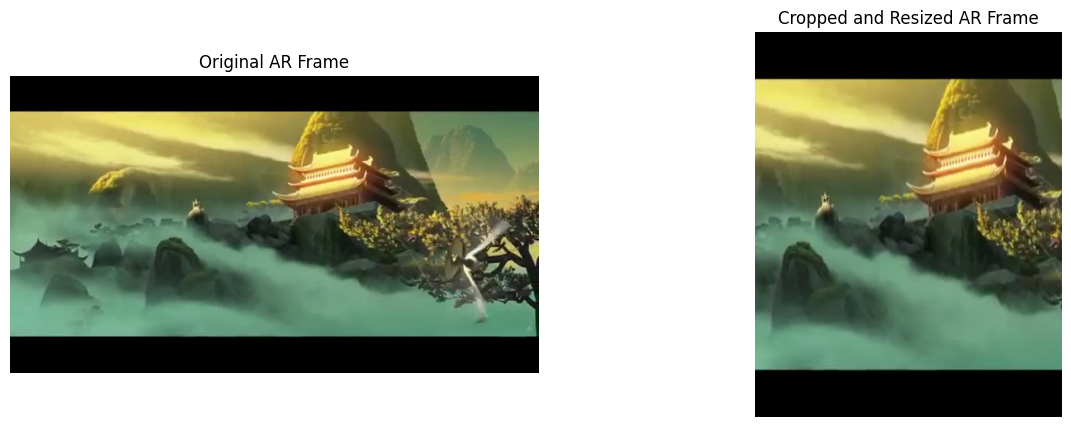

In [29]:
cropped_ar_frame = crop_frame(ar_frame, w_book, h_book)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.imshow(ar_frame)
ax1.set_title('Original AR Frame')
ax1.axis('off')

ax2.imshow(cropped_ar_frame)
ax2.set_title('Cropped and Resized AR Frame')
ax2.axis('off')
plt.show()

### Overlay the First Frame of the Two Videos
- Replace the computer vision book in the first video frame with the first cropped frame of the movie video to make the AR Effect.

To overlay 2 images: 
- The original image will have the book cover removed to completely black using a mask.
- The mask will be white, with the book polygon as black
- AND operation will be applied to keep background
- The new warped layer will be added on the background

In [30]:
def overlay_frame(ar_frame, H, corners_dst, visualize=False):
    # transform frame with homography matrix
    warped_ar = cv2.warpPerspective(cropped_ar_frame, H, (book_frame.shape[1], book_frame.shape[0]))

    # full white picture
    mask = np.full_like(book_frame, 255, dtype=np.uint8)

    # fill the book with void
    cv2.fillConvexPoly(mask, corners_dst, (0, 0, 0))

    # AND to get video frame with book cover removed
    background = cv2.bitwise_and(book_frame, mask)

    # isolate the warped AR frame to exactly the polygon shape
    # foreground = cv2.bitwise_and(warped_ar, mask) # not needed: warped_ar is already black outside the polygon

    # combine the background and the transformed AR frame
    final_ar_frame = cv2.add(background, warped_ar)
    
    if visualize:
        fig, axs = plt.subplots(2, 2, figsize=(10, 10))
        axs = axs.flatten()

        axs[0].imshow(warped_ar)
        axs[0].set_title('Warped AR Frame')
        axs[0].axis('off')

        axs[1].imshow(mask)
        axs[1].set_title('Mask for Background')
        axs[1].axis('off')

        axs[2].imshow(background)
        axs[2].set_title('Video Frame with Hole')
        axs[2].axis('off')

        axs[3].imshow(final_ar_frame)
        axs[3].set_title('First Frame Overlay')
        axs[3].axis('off')

        plt.tight_layout()
        plt.show()

    return final_ar_frame

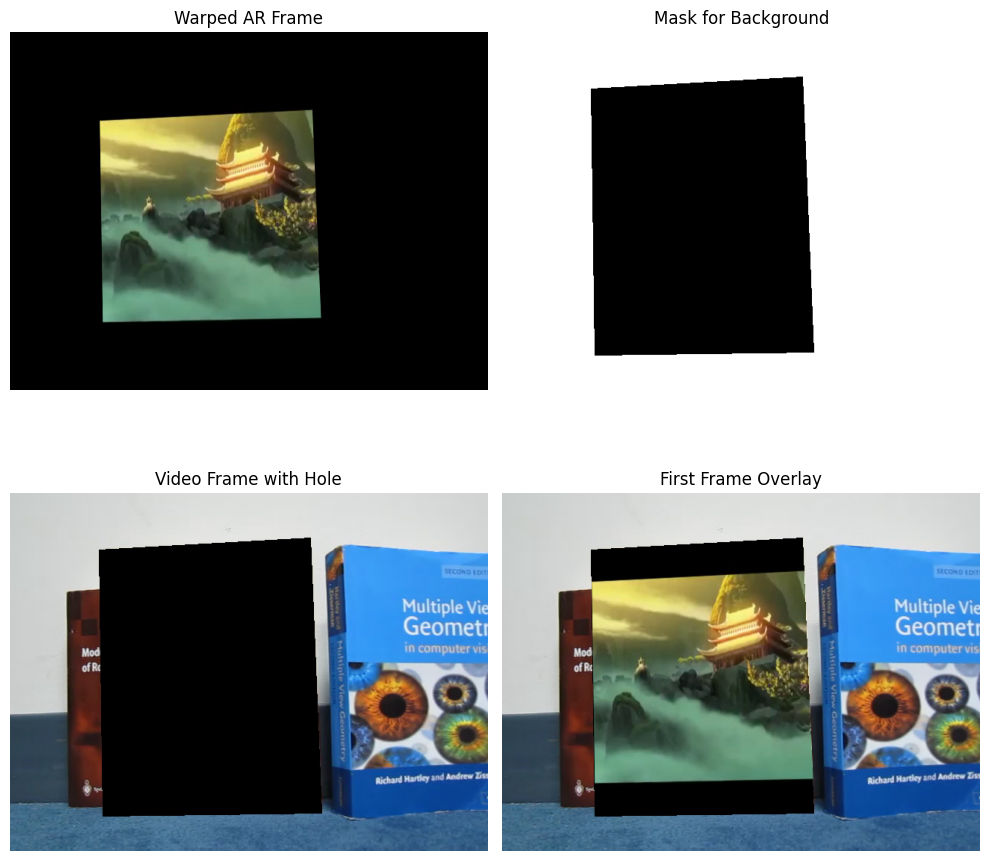

In [31]:
final_ar_frame = overlay_frame(cropped_ar_frame, H, corners_dst, visualize=True)

### Creating AR Application
- Overlay each cropped video frame to its corresponding frame of the book video
- Get the new location of the book in the following frame. 
- Compute the homography matrix between the vision book cover and all the frames.
- Overlay each frame.

In [32]:
# Re-open both videos from the start
book_vid2 = cv2.VideoCapture('data/book.mov')
ar_vid2   = cv2.VideoCapture('data/ar_source.mov')

fps      = book_vid2.get(cv2.CAP_PROP_FPS)
frame_w  = int(book_vid2.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_h  = int(book_vid2.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_book = int(book_vid2.get(cv2.CAP_PROP_FRAME_COUNT))
total_ar   = int(ar_vid2.get(cv2.CAP_PROP_FRAME_COUNT))
print(f'Book video:  {total_book} frames  {frame_w}x{frame_h}  {fps:.1f} fps')
print(f'AR video:    {total_ar} frames')

# Output video writer (mp4v codec -> .mp4)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('data/ar_output.mp4', fourcc, fps, (frame_w, frame_h))

frame_count = 0

while True:
    ret_b, b_bgr = book_vid2.read()
    ret_a, a_bgr = ar_vid2.read()

    # stop when either video ends
    if not ret_b or not ret_a:
        break

    b_rgb = cv2.cvtColor(b_bgr, cv2.COLOR_BGR2RGB)
    a_rgb = cv2.cvtColor(a_bgr, cv2.COLOR_BGR2RGB)

    # --- feature matching for this book frame ---
    gray_b = cv2.cvtColor(b_bgr, cv2.COLOR_BGR2GRAY)
    kp_b, des_b = sift.detectAndCompute(gray_b, None)

    matches_f = bf.knnMatch(des1, des_b, k=2)
    good_f = sorted(
        [m for m, n in matches_f if m.distance < 0.75 * n.distance],
        key=lambda x: x.distance
    )[:50]

    if len(good_f) < 4:
        out.write(b_bgr)
        frame_count += 1
        continue

    src_f = np.float32([kp1[m.queryIdx].pt for m in good_f])
    dst_f = np.float32([kp_b[m.trainIdx].pt for m in good_f])

    # --- RANSAC: reject geometric outliers before computing H ---
    # findHomography with RANSAC returns an inlier mask; we use only inliers
    # for our own least-squares compute_homography_parameters call so that
    # a handful of bad matches can never skew the result.
    _, inlier_mask = cv2.findHomography(src_f, dst_f, cv2.RANSAC, 5.0)
    if inlier_mask is None:
        out.write(b_bgr)
        frame_count += 1
        continue
    inliers = inlier_mask.ravel().astype(bool)
    if inliers.sum() < 4:
        out.write(b_bgr)
        frame_count += 1
        continue
    src_f = src_f[inliers]
    dst_f = dst_f[inliers]

    # --- compute H from RANSAC-filtered inliers ---
    H_f = compute_homography_parameters(src_f, dst_f)

    # --- map cover corners into this frame ---
    cover_corners = [[0, 0], [w_book - 1, 0], [w_book - 1, h_book - 1], [0, h_book - 1]]
    corners_f = []
    for cx, cy in cover_corners:
        p = np.dot(H_f, [cx, cy, 1.0])
        p /= p[2]
        corners_f.append([p[0], p[1]])
    corners_array_f = np.array(corners_f)
    corners_dst_f   = corners_array_f.astype(np.int32)

    # --- crop AR frame to book aspect ratio ---
    bw_f = np.linalg.norm(corners_array_f[1] - corners_array_f[0])  # TL->TR
    bh_f = np.linalg.norm(corners_array_f[3] - corners_array_f[0])  # TL->BL
    book_asp_f = bw_f / bh_f if bh_f > 0 else w_book / h_book

    h_a, w_a = a_rgb.shape[:2]
    ar_asp_f  = w_a / h_a

    if ar_asp_f > book_asp_f:
        cw_f = int(h_a * book_asp_f)
        ch_f = h_a
    else:
        cw_f = w_a
        ch_f = int(w_a / book_asp_f)

    cropped_f = crop_frame(a_rgb, cw_f, ch_f)
    cropped_f = cv2.resize(cropped_f, (w_book, h_book))

    # --- warp + overlay ---
    warped_f = cv2.warpPerspective(cropped_f, H_f, (frame_w, frame_h))
    mask_f   = np.full((frame_h, frame_w, 3), 255, dtype=np.uint8)
    cv2.fillConvexPoly(mask_f, corners_dst_f, (0, 0, 0))
    bg_f     = cv2.bitwise_and(b_rgb, mask_f)
    result_f = cv2.add(bg_f, warped_f)

    # write as BGR
    out.write(cv2.cvtColor(result_f, cv2.COLOR_RGB2BGR))
    frame_count += 1

    if frame_count % 20 == 0:
        print(f'  processed {frame_count} / {min(total_book, total_ar)} frames...')

book_vid2.release()
ar_vid2.release()
out.release()
print(f'Done! {frame_count} frames written -> data/ar_output.mp4')


Book video:  641 frames  640x480  30.0 fps
AR video:    511 frames
  processed 20 / 511 frames...
  processed 40 / 511 frames...
  processed 60 / 511 frames...
  processed 80 / 511 frames...
  processed 100 / 511 frames...
  processed 120 / 511 frames...
  processed 140 / 511 frames...
  processed 160 / 511 frames...
  processed 180 / 511 frames...
  processed 200 / 511 frames...
  processed 220 / 511 frames...
  processed 240 / 511 frames...
  processed 260 / 511 frames...
  processed 280 / 511 frames...
  processed 300 / 511 frames...
  processed 320 / 511 frames...
  processed 340 / 511 frames...
  processed 360 / 511 frames...
  processed 380 / 511 frames...
  processed 400 / 511 frames...
  processed 420 / 511 frames...
  processed 440 / 511 frames...
  processed 460 / 511 frames...
  processed 480 / 511 frames...
  processed 500 / 511 frames...
Done! 511 frames written -> data/ar_output.mp4


Book projection in video: 283.1 x 356.1 px
Book aspect ratio (w/h):  0.7952
AR video dimensions:      640 x 360
Crop window: 286 x 360
cropped_ar_frame shape: (440, 350, 3)


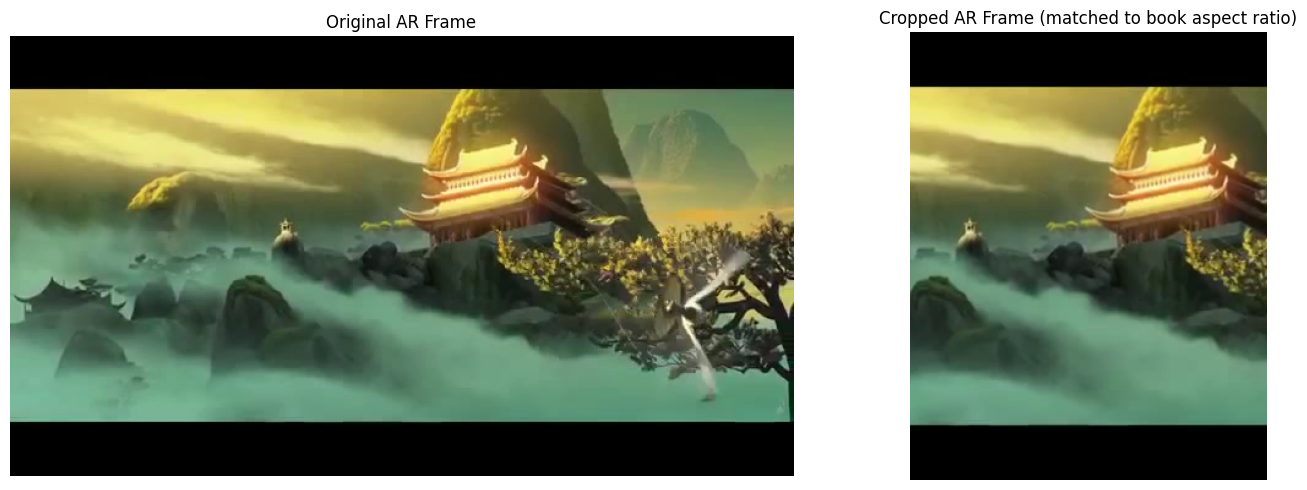

In [33]:
# Part 1.4: Crop AR Video Frames
# Derive crop dimensions from the projected book corners (corners_transformed)
corners_array = np.array(corners_transformed)

book_w_in_vid = np.linalg.norm(corners_array[1] - corners_array[0])  # TL -> TR
book_h_in_vid = np.linalg.norm(corners_array[3] - corners_array[0])  # TL -> BL

print(f'Book projection in video: {book_w_in_vid:.1f} x {book_h_in_vid:.1f} px')
print(f'Book aspect ratio (w/h):  {book_w_in_vid / book_h_in_vid:.4f}')
print(f'AR video dimensions:      {w_ar} x {h_ar}')

ar_aspect   = w_ar / h_ar
book_aspect = book_w_in_vid / book_h_in_vid

if ar_aspect > book_aspect:
    # AR frame is wider than the book -> keep full height, crop width
    crop_w = int(h_ar * book_aspect)
    crop_h = h_ar
else:
    # AR frame is taller than the book -> keep full width, crop height
    crop_w = w_ar
    crop_h = int(w_ar / book_aspect)

print(f'Crop window: {crop_w} x {crop_h}')

# crop central region, then resize to cover dimensions for warpPerspective
cropped_ar_frame = crop_frame(ar_frame, crop_w, crop_h)
cropped_ar_frame = cv2.resize(cropped_ar_frame, (w_book, h_book))

print(f'cropped_ar_frame shape: {cropped_ar_frame.shape}')  # (h_book, w_book, 3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.imshow(ar_frame)
ax1.set_title('Original AR Frame')
ax1.axis('off')

ax2.imshow(cropped_ar_frame)
ax2.set_title('Cropped AR Frame (matched to book aspect ratio)')
ax2.axis('off')

plt.tight_layout()
plt.show()
